# Exploratory Data Analysis (EDA)

This notebook performs comprehensive exploratory data analysis on the Brazilian E-commerce dataset.

## Requirements

To run this notebook successfully, install the required packages:

```bash
pip install numpy pandas matplotlib seaborn
```

This notebook imports those packages directly, so make sure they are available in your current Python environment before running the cells.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
from pathlib import Path

# Resolve the project root so data loading works from any working directory
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == 'notebooks' else cwd
data_path = project_root / 'data' / 'processed' / 'master_dataset.csv'

# Load the master dataset
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset Shape: (112650, 61)
Memory Usage: 195.59 MB


## 1. Dataset Overview

In [3]:
# Basic info
print("DATASET INFO:")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Data Types:")
print(df.dtypes.value_counts())

print("\nMISSING VALUES:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

DATASET INFO:
Shape: (112650, 61)
Columns: 61
Data Types:
float64    32
object     20
int64       9
Name: count, dtype: int64

MISSING VALUES:


                                       Missing Count  Missing %
actual_delivery_days                            2454   2.178429
delivery_delay_vs_estimate_days                 2454   2.178429
order_delivered_customer_date                   2454   2.178429
delivery_time_days                              2454   2.178429
order_delivered_carrier_date                    1194   1.059920
dominant_sentiment                               942   0.836218
negative_review_count                            942   0.836218
review_row_count                                 942   0.836218
max_review_score                                 942   0.836218
min_review_score                                 942   0.836218
avg_review_score                                 942   0.836218
order_approved_at                                 15   0.013316
dominant_payment_type                              3   0.002663
total_payment_value                                3   0.002663
payment_row_count                       

In [4]:
# Sample data
print("SAMPLE DATA:")
display(df.head())

print("\nCOLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

SAMPLE DATA:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,is_delivered_clean,order_stage,is_completed_order,is_late_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,state_city,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total_value,is_expensive_item,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,product_category_name_english,order_item_count,distinct_products,distinct_sellers,order_items_total_value,order_items_total_freight,average_item_price,average_item_freight,max_item_price,min_item_price,total_payment_value,payment_row_count,payment_method_count,dominant_payment_type,average_payment_installments,average_payment_value_per_installment,credit_card_payment_rows,full_payment_rows,avg_review_score,min_review_score,max_review_score,review_row_count,negative_review_count,dominant_sentiment,delivery_delay_vs_estimate_days,actual_delivery_days
0,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,NaN,2016-10-20,NaN,0,shipped_not_delivered,0,0,b7d76e111c89f7ebf14761390f0f7d17,69309,boa vista,rr,rr_boa vista,1,c1488892604e4ba5cff5b4eb4d595400,1554a68530182680ad5c8b042c3ab563,2016-10-26 18:25:19,39.99,31.67,71.66,0,moveis_decoracao,59.0,426.0,2.0,1400.0,32.0,6.0,28.0,5376.0,furniture_decor,2,2,1,136.23,63.34,36.445,31.67,39.99,32.90,136.23,1.0,1.0,credit_card,1.0,136.23,1.0,1.0,1.0,1.0,1.0,1.0,1.0,negative,NaN,NaN
1,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,NaN,2016-10-20,NaN,0,shipped_not_delivered,0,0,b7d76e111c89f7ebf14761390f0f7d17,69309,boa vista,rr,rr_boa vista,2,f293394c72c9b5fafd7023301fc21fc2,1554a68530182680ad5c8b042c3ab563,2016-10-26 18:25:19,32.90,31.67,64.57,0,moveis_decoracao,41.0,754.0,3.0,1800.0,32.0,6.0,28.0,5376.0,furniture_decor,2,2,1,136.23,63.34,36.445,31.67,39.99,32.90,136.23,1.0,1.0,credit_card,1.0,136.23,1.0,1.0,1.0,1.0,1.0,1.0,1.0,negative,NaN,NaN
2,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,NaN,NaN,2016-10-28,NaN,0,approved_not_shipped,0,0,4854e9b3feff728c13ee5fc7d1547e92,99025,passo fundo,rs,rs_passo fundo,1,f3c2d01a84c947b078e32bbef0718962,a425f92c199eb576938df686728acd20,2016-09-19 00:15:34,59.50,15.56,75.06,0,telefonia,42.0,381.0,1.0,700.0,25.0,2.0,25.0,1250.0,telephony,1,1,1,75.06,15.56,59.500,15.56,59.50,59.50,75.06,1.0,1.0,credit_card,3.0,25.02,1.0,0.0,1.0,1.0,1.0,1.0,1.0,negative,NaN,NaN
3,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.0,1,delivered,1,1,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,sp,sp_sao joaquim da barra,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82,0,beleza_saude,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,4096.0,health_beauty,3,1,1,143.46,8.49,44.990,2.83,44.99,44.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,negative,36.0,54.0
4,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54.0,1,delivered,1,1,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,sp,sp_sao joaquim da barra,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82,0,beleza_saude,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,4096.0,health_beauty,3,1,1,143.46,8.49,44.990,2.83,44.99,44.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,negative,36.0,54.0



COLUMN NAMES:
 1. order_id
 2. customer_id
 3. order_status
 4. order_purchase_timestamp
 5. order_approved_at
 6. order_delivered_carrier_date
 7. order_delivered_customer_date
 8. order_estimated_delivery_date
 9. delivery_time_days
10. is_delivered_clean
11. order_stage
12. is_completed_order
13. is_late_delivery
14. customer_unique_id
15. customer_zip_code_prefix
16. customer_city
17. customer_state
18. state_city
19. order_item_id
20. product_id
21. seller_id
22. shipping_limit_date
23. price
24. freight_value
25. item_total_value
26. is_expensive_item
27. product_category_name
28. product_name_lenght
29. product_description_lenght
30. product_photos_qty
31. product_weight_g
32. product_length_cm
33. product_height_cm
34. product_width_cm
35. product_volume_cm3
36. product_category_name_english
37. order_item_count
38. distinct_products
39. distinct_sellers
40. order_items_total_value
41. order_items_total_freight
42. average_item_price
43. average_item_freight
44. max_item_price

## 2. Univariate Analysis

In [5]:
# Numerical columns analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (41): ['delivery_time_days', 'is_delivered_clean', 'is_completed_order', 'is_late_delivery', 'customer_zip_code_prefix', 'order_item_id', 'price', 'freight_value', 'item_total_value', 'is_expensive_item', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_volume_cm3', 'order_item_count', 'distinct_products', 'distinct_sellers', 'order_items_total_value', 'order_items_total_freight', 'average_item_price', 'average_item_freight', 'max_item_price', 'min_item_price', 'total_payment_value', 'payment_row_count', 'payment_method_count', 'average_payment_installments', 'average_payment_value_per_installment', 'credit_card_payment_rows', 'full_payment_rows', 'avg_review_score', 'min_review_score', 'max_review_score', 'review_row_count', 'negative_review_count', 'delivery_delay_vs_estimate_days', 'actual_delivery_days']

Categorical columns (20): ['order_id', 'cust

In [6]:
# Statistical summary for numerical columns
print("NUMERICAL COLUMNS SUMMARY:")
display(df[numerical_cols].describe())

NUMERICAL COLUMNS SUMMARY:


,delivery_time_days,is_delivered_clean,is_completed_order,is_late_delivery,customer_zip_code_prefix,order_item_id,price,freight_value,item_total_value,is_expensive_item,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,order_item_count,distinct_products,distinct_sellers,order_items_total_value,order_items_total_freight,average_item_price,average_item_freight,max_item_price,min_item_price,total_payment_value,payment_row_count,payment_method_count,average_payment_installments,average_payment_value_per_installment,credit_card_payment_rows,full_payment_rows,avg_review_score,min_review_score,max_review_score,review_row_count,negative_review_count,delivery_delay_vs_estimate_days,actual_delivery_days
count,110196.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112647.000000,112647.000000,112647.000000,112647.000000,112647.000000,112647.000000,112647.000000,111708.000000,111708.000000,111708.000000,111708.000000,111708.000000,110196.000000,110196.000000
mean,12.007723,0.978216,0.978216,0.077364,35119.309090,1.197834,120.653739,19.990320,140.644059,0.048868,48.807625,785.122548,2.192499,2093.449356,30.152845,16.593191,22.996067,15242.312437,1.395668,1.088398,1.029898,180.244628,27.285033,120.653739,19.990320,122.291711,119.346417,180.281186,1.043978,1.022087,3.001417,92.436344,0.770274,0.520360,4.033128,4.030660,4.035593,1.005944,0.162110,-12.030201,12.007723
std,9.451455,0.145979,0.145979,0.267169,29866.120801,0.705124,183.633928,15.806405,190.724394,0.215593,9.957478,647.881840,1.715141,3751.338501,16.152290,13.442486,11.706394,23416.914409,1.120101,0.375290,0.186050,272.829911,33.218827,183.075301,15.614028,185.049766,182.860048,272.849042,0.384391,0.146966,2.785456,200.345315,0.427649,0.647867,1.386119,1.388914,1.385728,0.077564,0.370129,10.160157,9.451455
min,0.000000,0.000000,0.000000,0.000000,1003.000000,1.000000,0.850000,0.000000,6.080000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,168.000000,1.000000,1.000000,1.000000,9.590000,0.000000,0.850000,0.000000,0.850000,0.850000,9.590000,1.000000,1.000000,0.000000,1.737500,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-147.000000,0.000000
25%,6.000000,1.000000,1.000000,0.000000,11310.000000,1.000000,39.900000,13.080000,55.220000,0.000000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,2852.000000,1.000000,1.000000,1.000000,65.620000,14.292500,39.950000,13.177500,39.990000,39.900000,65.670000,1.000000,1.000000,1.000000,29.034375,1.000000,0.000000,4.000000,4.000000,4.000000,1.000000,0.000000,-17.000000,6.000000
50%,10.000000,1.000000,1.000000,0.000000,24340.000000,1.000000,74.990000,16.260000,92.320000,0.000000,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,6480.000000,1.000000,1.000000,1.000000,114.440000,18.160000,74.990000,16.260000,76.800000,72.900000,114.440000,1.000000,1.000000,2.000000,54.985000,1.000000,0.000000,5.000000,5.000000,5.000000,1.000000,0.000000,-13.000000,10.000000
75%,15.000000,1.000000,1.000000,0.000000,59028.750000,1.000000,134.900000,21.150000,157.937500,0.000000,57.000000,981.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,18373.250000,1.000000,1.000000,1.000000,195.337500,29.220000,134.900000,21.100000,137.900000,130.000000,195.390000,1.000000,1.000000,4.000000,98.304500,1.000000,1.000000,5.000000,5.000000,5.000000,1.000000,0.000000,-7.000000,15.000000
max,209.000000,1.000000,1.000000,1.000000,99990.000000,21.000000,6735.000000,409.680000,6929.310000,1.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,296208

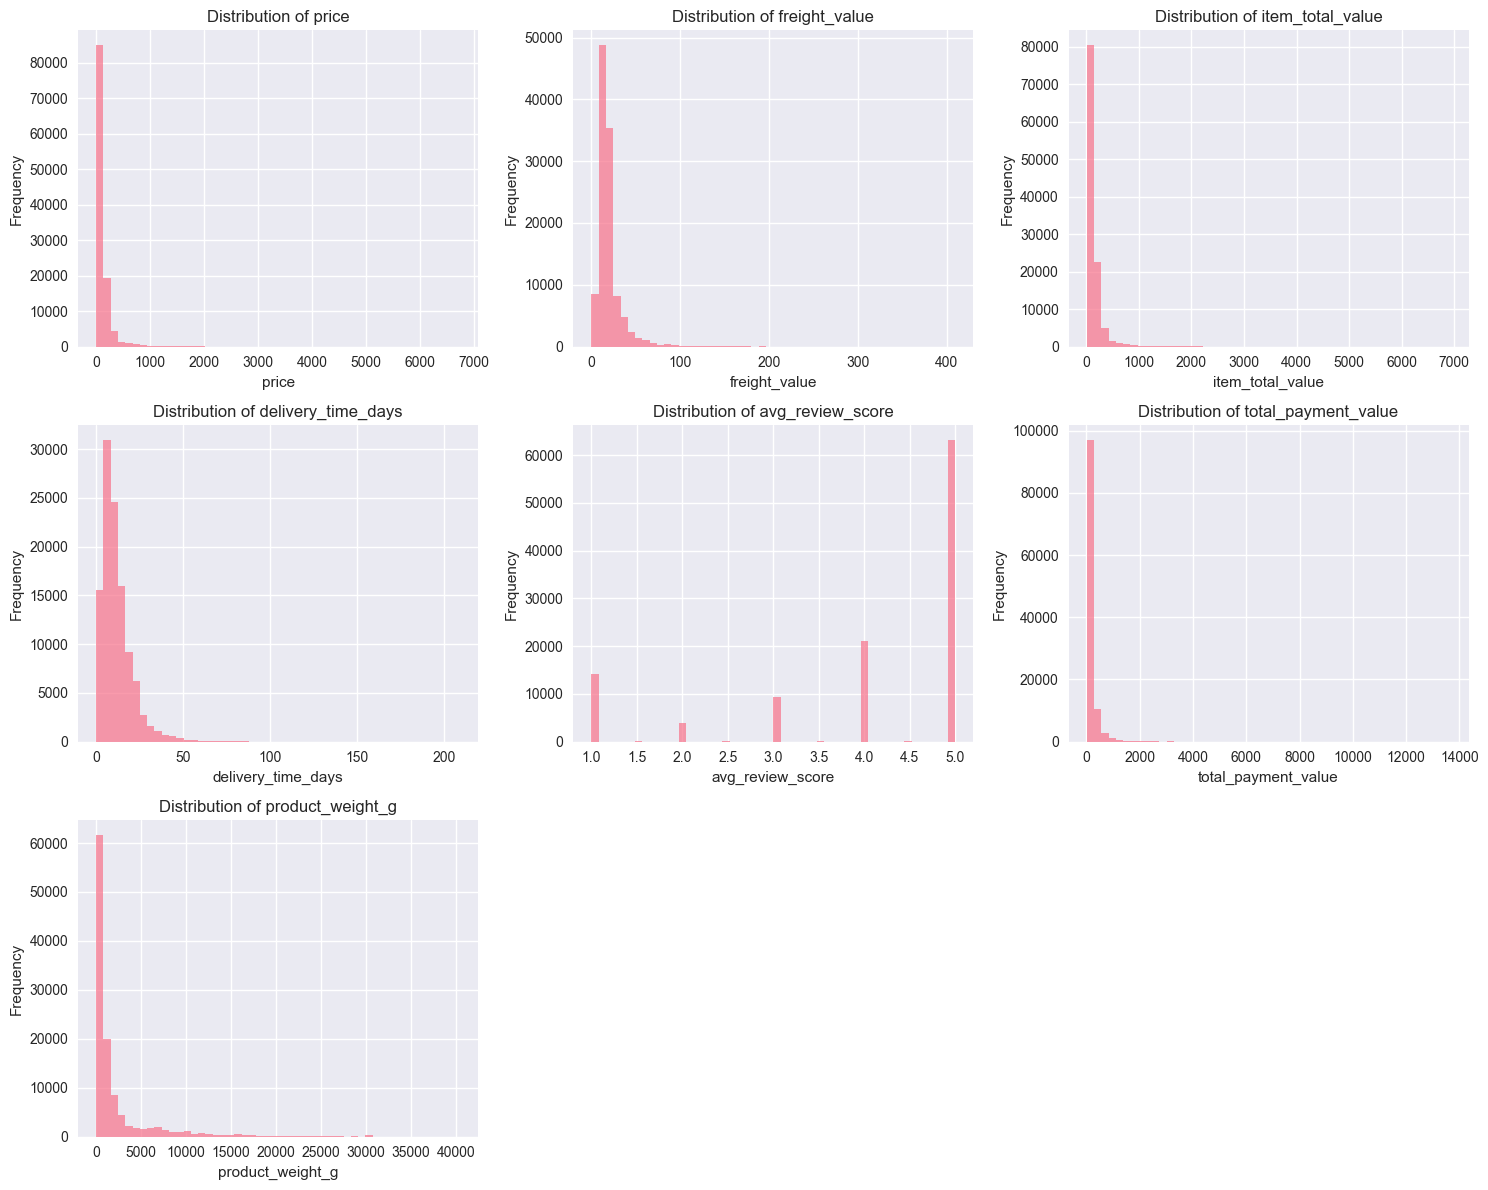

In [7]:
# Distribution plots for key numerical variables
key_numerical = ['price', 'freight_value', 'item_total_value', 'delivery_time_days', 
                'avg_review_score', 'total_payment_value', 'product_weight_g']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(key_numerical):
    if col in df.columns:
        df[col].hist(bins=50, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Remove empty subplots
for j in range(len(key_numerical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

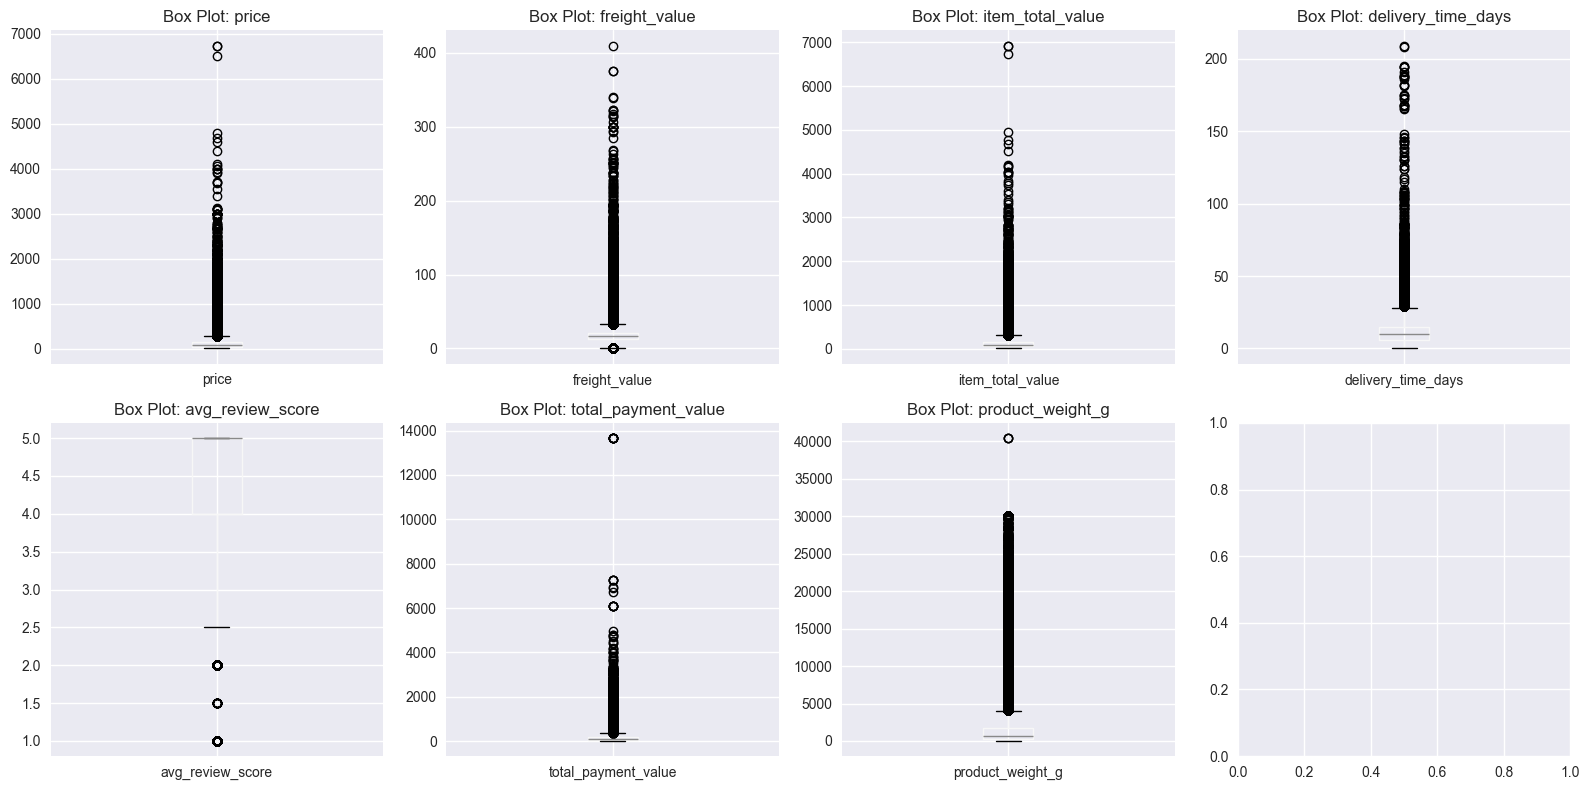

In [8]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(key_numerical):
    if col in df.columns and i < 8:
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(f'Box Plot: {col}')

plt.tight_layout()
plt.show()


ORDER_STATUS VALUE COUNTS:
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64


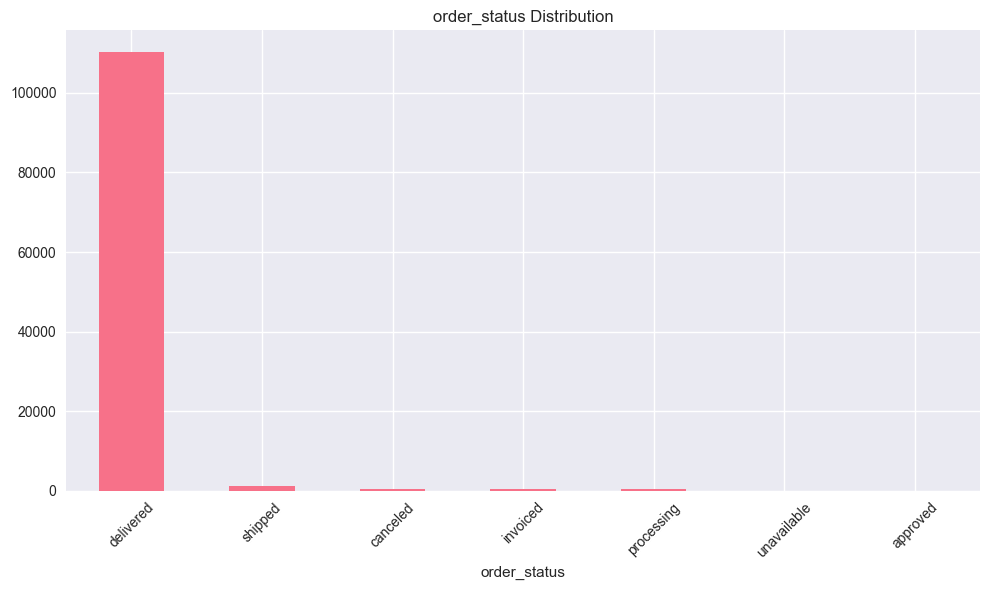


CUSTOMER_STATE VALUE COUNTS:
customer_state
sp    47449
rj    14579
mg    13129
rs     6235
pr     5740
sc     4176
ba     3799
df     2406
go     2333
es     2256
Name: count, dtype: int64


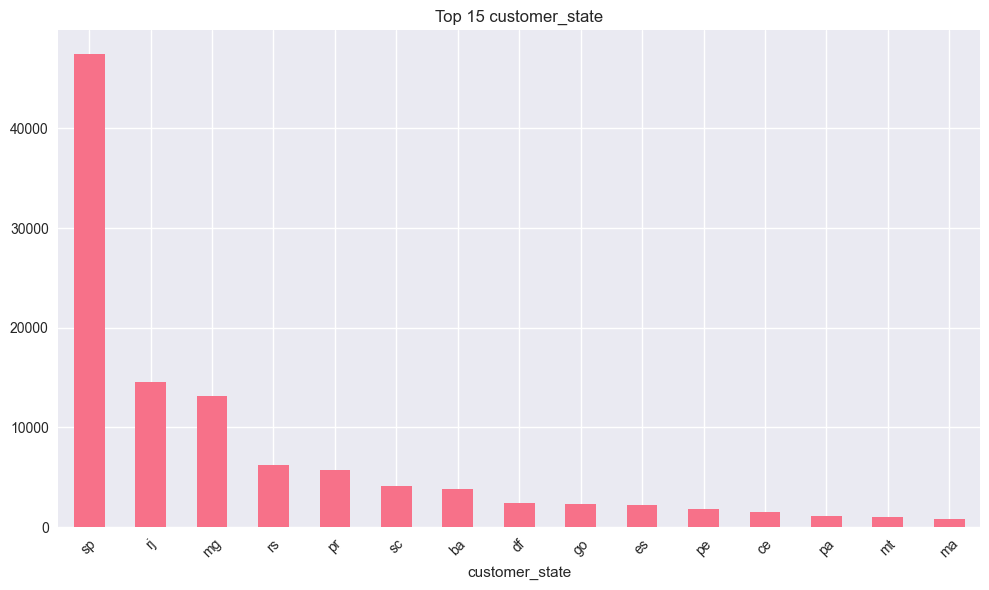


PRODUCT_CATEGORY_NAME VALUE COUNTS:
product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64


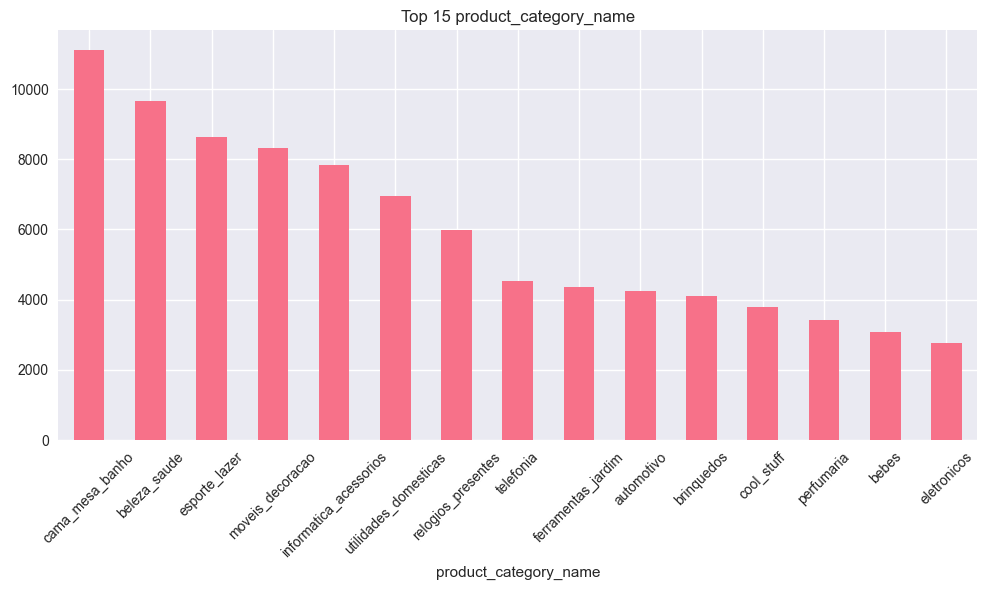


DOMINANT_PAYMENT_TYPE VALUE COUNTS:
dominant_payment_type
credit_card    86017
boleto         22867
voucher         2074
debit_card      1689
Name: count, dtype: int64


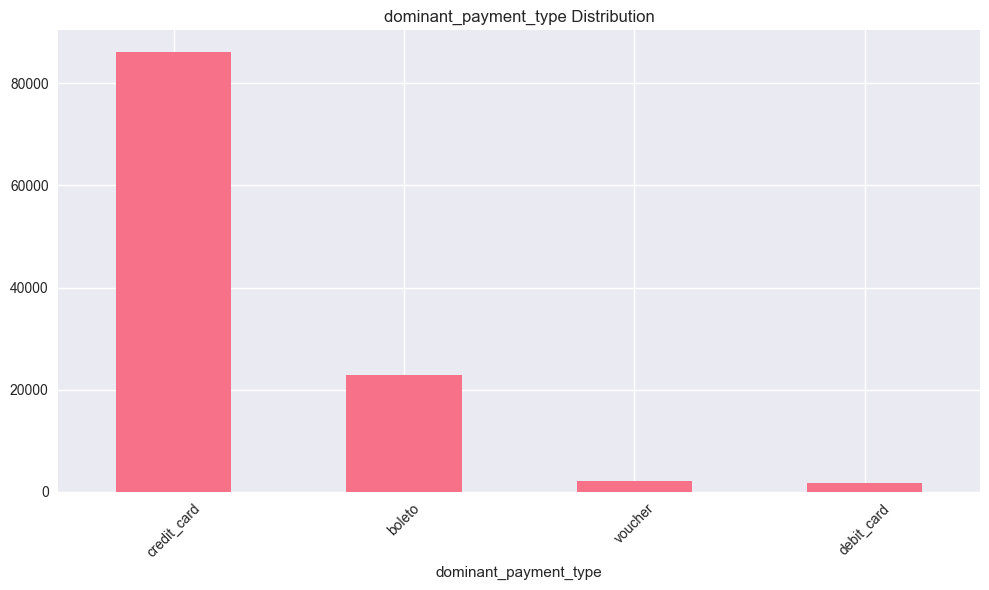


DOMINANT_SENTIMENT VALUE COUNTS:
dominant_sentiment
positive    84289
negative    18045
neutral      9374
Name: count, dtype: int64


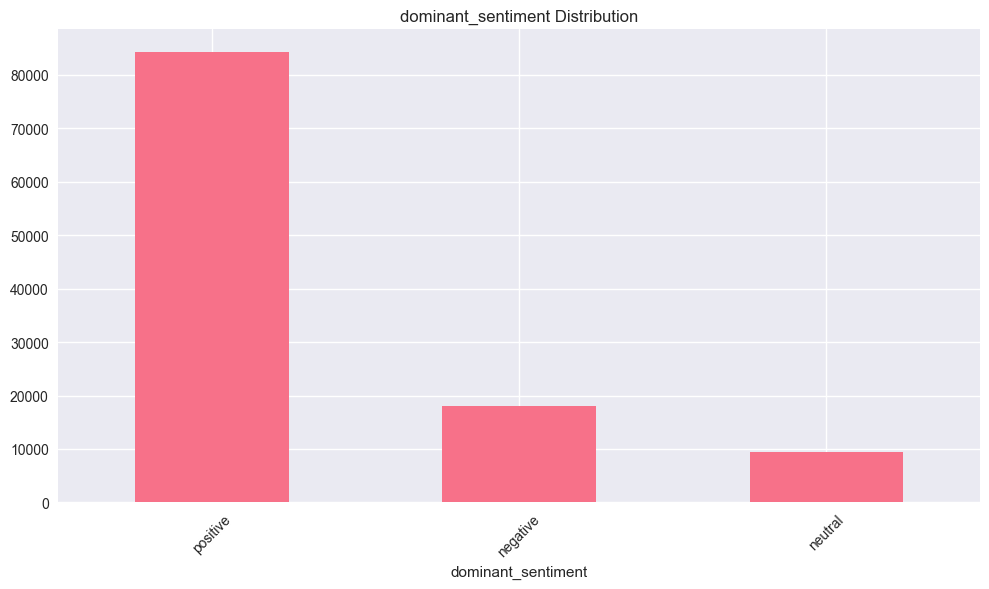


ORDER_STAGE VALUE COUNTS:
order_stage
delivered                110196
shipped_not_delivered      1261
approved_not_shipped       1193
Name: count, dtype: int64


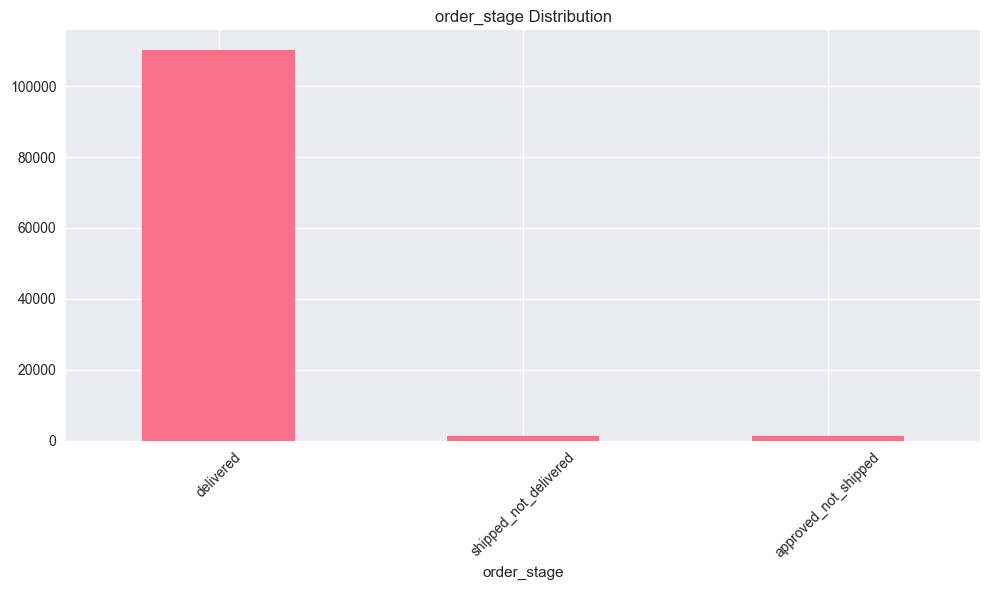

In [9]:
# Categorical variables analysis
key_categorical = ['order_status', 'customer_state', 'product_category_name', 
                  'dominant_payment_type', 'dominant_sentiment', 'order_stage']

for col in key_categorical:
    if col in df.columns:
        print(f"\n{col.upper()} VALUE COUNTS:")
        value_counts = df[col].value_counts()
        print(value_counts.head(10))
        
        # Plot
        plt.figure(figsize=(10, 6))
        if len(value_counts) > 15:
            value_counts.head(15).plot(kind='bar')
            plt.title(f'Top 15 {col}')
        else:
            value_counts.plot(kind='bar')
            plt.title(f'{col} Distribution')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## 3. Bivariate Analysis

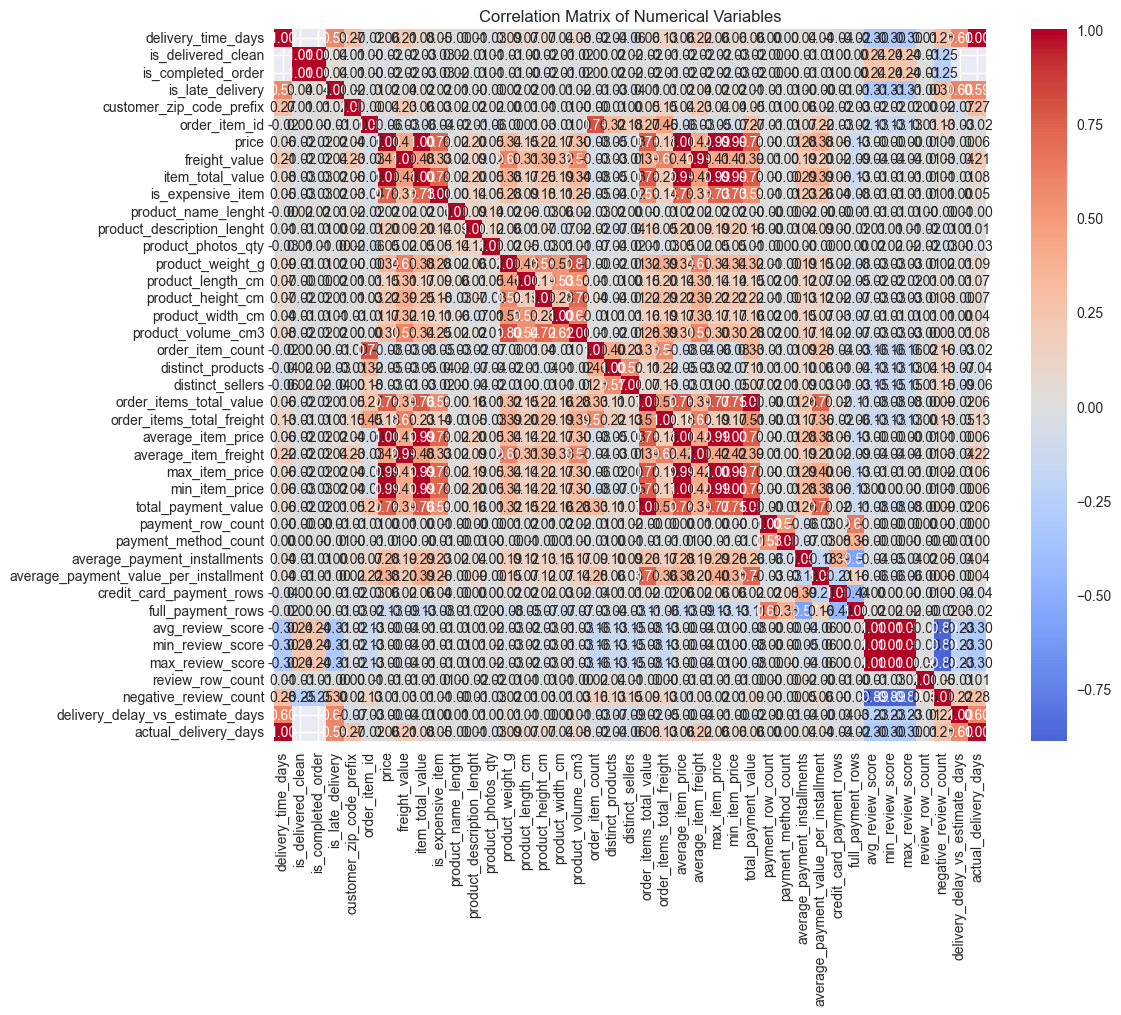

In [10]:
# Correlation matrix for numerical variables
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

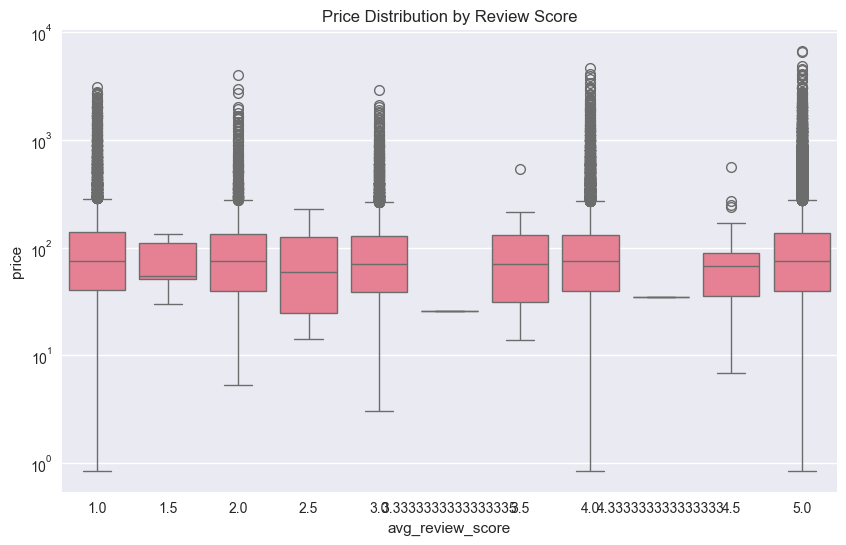

PRICE BY REVIEW SCORE:
                    mean  median     std
avg_review_score                        
1.000000          127.82   75.00  203.01
1.500000           73.84   53.90   33.81
2.000000          116.36   74.90  179.09
2.500000           79.08   58.90   64.09
3.000000          109.94   69.99  141.34
3.333333           26.00   26.00     NaN
3.500000           98.64   69.90  101.41
4.000000          118.84   75.00  178.13
4.333333           34.99   34.99     NaN
4.500000           78.28   66.90   78.98
5.000000          121.44   74.99  184.85


In [11]:
# Price vs Review Score
if 'price' in df.columns and 'avg_review_score' in df.columns:
    # Filter out zero review scores
    df_filtered = df[df['avg_review_score'] > 0].copy()
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_filtered, x='avg_review_score', y='price')
    plt.title('Price Distribution by Review Score')
    plt.yscale('log')
    plt.show()
    
    # Statistical summary
    print("PRICE BY REVIEW SCORE:")
    print(df_filtered.groupby('avg_review_score')['price'].agg(['mean', 'median', 'std']).round(2))

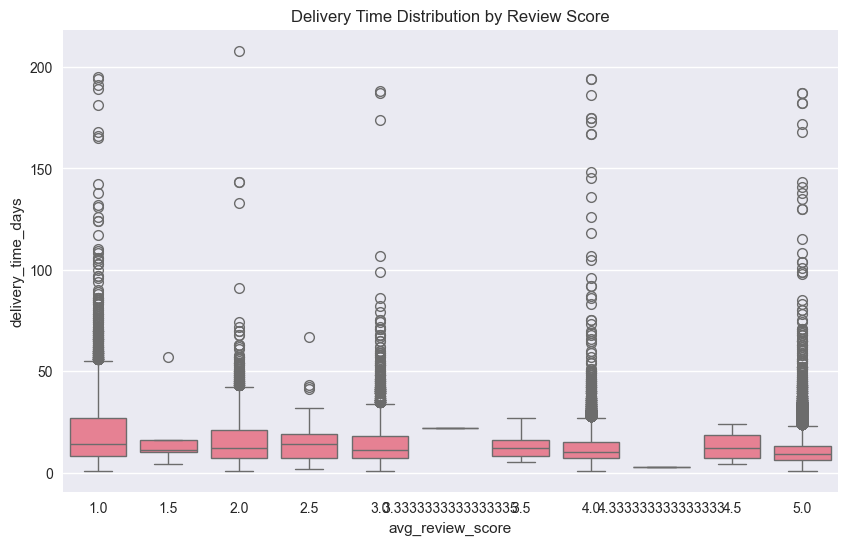

DELIVERY TIME BY REVIEW SCORE:
                   mean  median    std
avg_review_score                      
1.000000          19.17    14.0  15.23
1.500000          14.39    11.0  11.09
2.000000          15.35    12.0  12.10
2.500000          16.00    14.0  13.01
3.000000          13.57    11.0   9.69
3.333333          22.00    22.0    NaN
3.500000          12.48    12.0   6.60
4.000000          11.75    10.0   8.25
4.333333           3.00     3.0    NaN
4.500000          12.46    12.0   5.83
5.000000          10.18     9.0   6.86


In [12]:
# Delivery time vs Review Score
if 'delivery_time_days' in df.columns and 'avg_review_score' in df.columns:
    # Filter out zero review scores and delivery times
    df_filtered = df[(df['avg_review_score'] > 0) & (df['delivery_time_days'] > 0)].copy()
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_filtered, x='avg_review_score', y='delivery_time_days')
    plt.title('Delivery Time Distribution by Review Score')
    plt.show()
    
    print("DELIVERY TIME BY REVIEW SCORE:")
    print(df_filtered.groupby('avg_review_score')['delivery_time_days'].agg(['mean', 'median', 'std']).round(2))

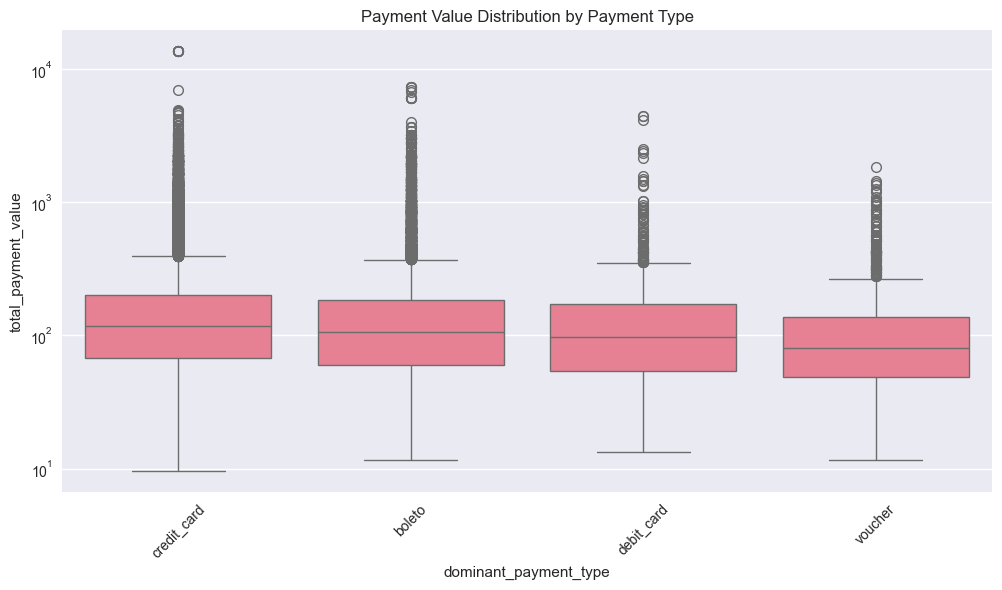

PAYMENT VALUE BY PAYMENT TYPE:
                         mean  median  count
dominant_payment_type                       
boleto                 177.54  105.87  22867
credit_card            183.04  117.65  86017
debit_card             150.08   97.55   1689
voucher                120.75   81.08   2074


In [13]:
# Payment type vs Order value
if 'dominant_payment_type' in df.columns and 'total_payment_value' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='dominant_payment_type', y='total_payment_value')
    plt.title('Payment Value Distribution by Payment Type')
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.show()
    
    print("PAYMENT VALUE BY PAYMENT TYPE:")
    print(df.groupby('dominant_payment_type')['total_payment_value'].agg(['mean', 'median', 'count']).round(2))

## 4. Geographic Analysis

TOP 10 STATES BY ORDER COUNT:


,Order_Count,Avg_Payment,Total_Revenue,Avg_Review_Score,Avg_Delivery_Days
customer_state,,,,,
sp,47449,160.12,7597209.66,4.13,8.26
rj,14579,189.95,2769347.44,3.81,14.69
mg,13129,177.18,2326151.64,4.09,11.52
rs,6235,184.01,1147277.00,4.05,14.71
pr,5740,185.47,1064603.99,4.11,11.48
sc,4176,188.30,786343.71,4.00,14.52
ba,3799,209.90,797410.36,3.81,18.77
df,2406,179.81,432623.73,4.01,12.50
go,2333,220.27,513879.00,3.99,14.95


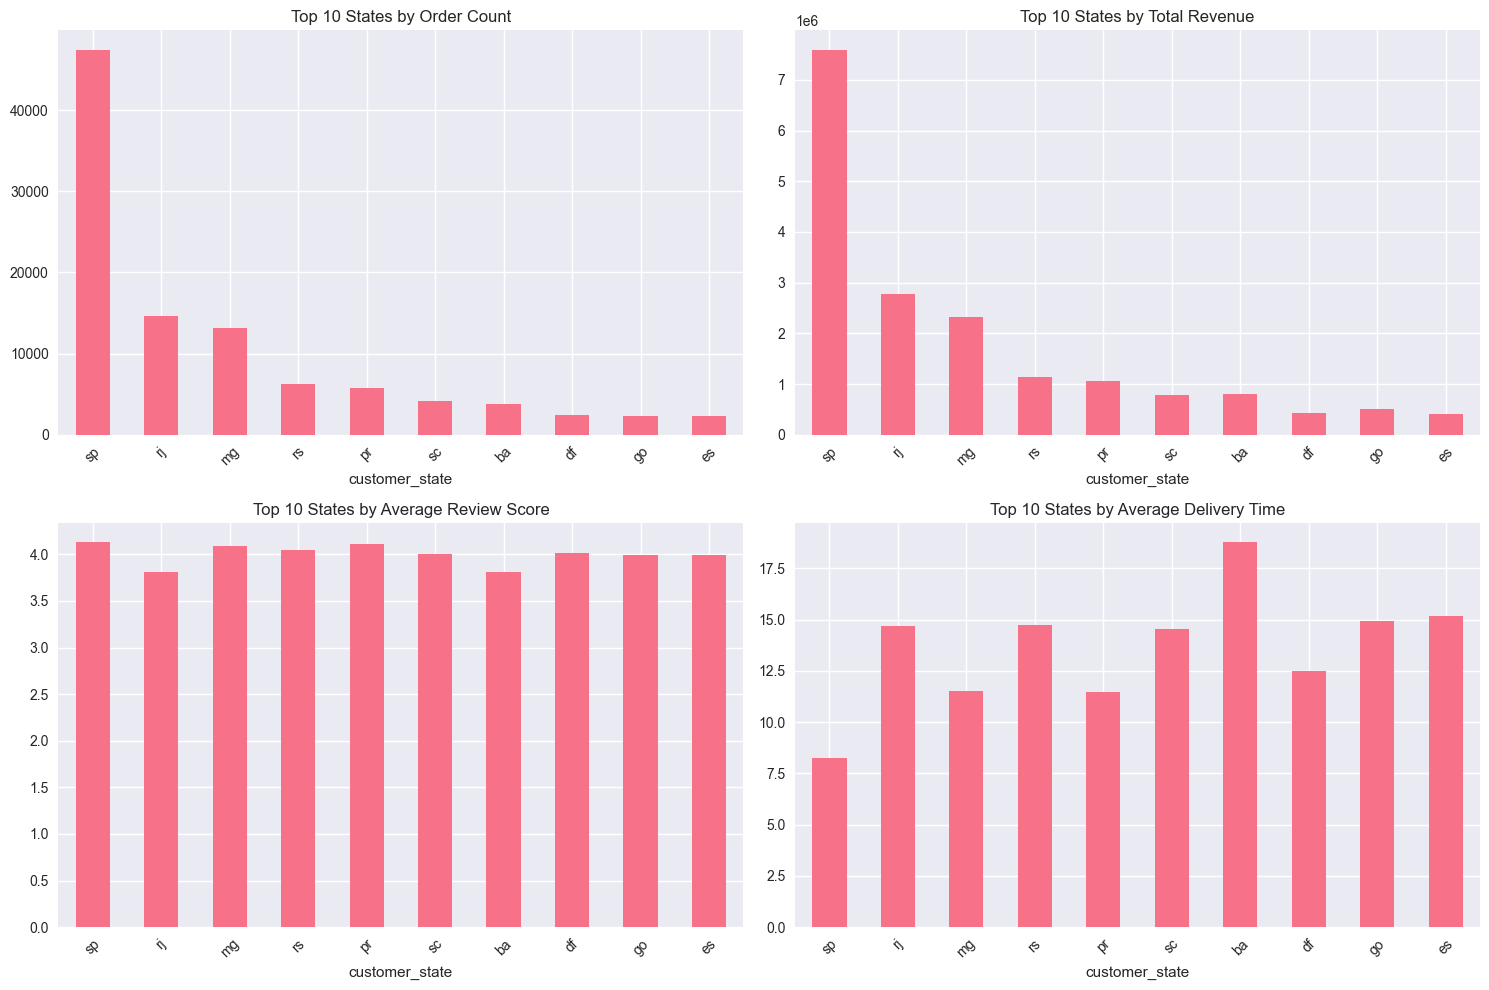

In [14]:
# State-wise analysis
if 'customer_state' in df.columns:
    state_analysis = df.groupby('customer_state').agg({
        'order_id': 'count',
        'total_payment_value': ['mean', 'sum'],
        'avg_review_score': 'mean',
        'delivery_time_days': 'mean'
    }).round(2)
    
    state_analysis.columns = ['Order_Count', 'Avg_Payment', 'Total_Revenue', 
                             'Avg_Review_Score', 'Avg_Delivery_Days']
    state_analysis = state_analysis.sort_values('Order_Count', ascending=False)
    
    print("TOP 10 STATES BY ORDER COUNT:")
    display(state_analysis.head(10))
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Orders by state
    state_analysis.head(10)['Order_Count'].plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Top 10 States by Order Count')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Revenue by state
    state_analysis.head(10)['Total_Revenue'].plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Top 10 States by Total Revenue')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Average review score by state
    state_analysis.head(10)['Avg_Review_Score'].plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title('Top 10 States by Average Review Score')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Average delivery time by state
    state_analysis.head(10)['Avg_Delivery_Days'].plot(kind='bar', ax=axes[1,1])
    axes[1,1].set_title('Top 10 States by Average Delivery Time')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 5. Product Analysis

TOP 15 PRODUCT CATEGORIES:


,Order_Count,Avg_Price,Total_Revenue,Avg_Review_Score,Avg_Freight
product_category_name_english,,,,,
bed_bath_table,11115,93.30,1712553.67,3.90,18.42
health_beauty,9670,130.16,1657373.12,4.14,18.88
sports_leisure,8641,114.34,1392127.56,4.11,19.51
furniture_decor,8334,87.56,1430176.39,3.91,20.73
computers_accessories,7827,116.51,1585330.45,3.93,18.82
housewares,6964,90.79,1094758.13,4.05,20.99
watches_gifts,5991,201.14,1429216.68,4.02,16.78
telephony,4545,71.21,486882.05,3.95,15.67
garden_tools,4347,111.63,838280.75,4.05,22.77


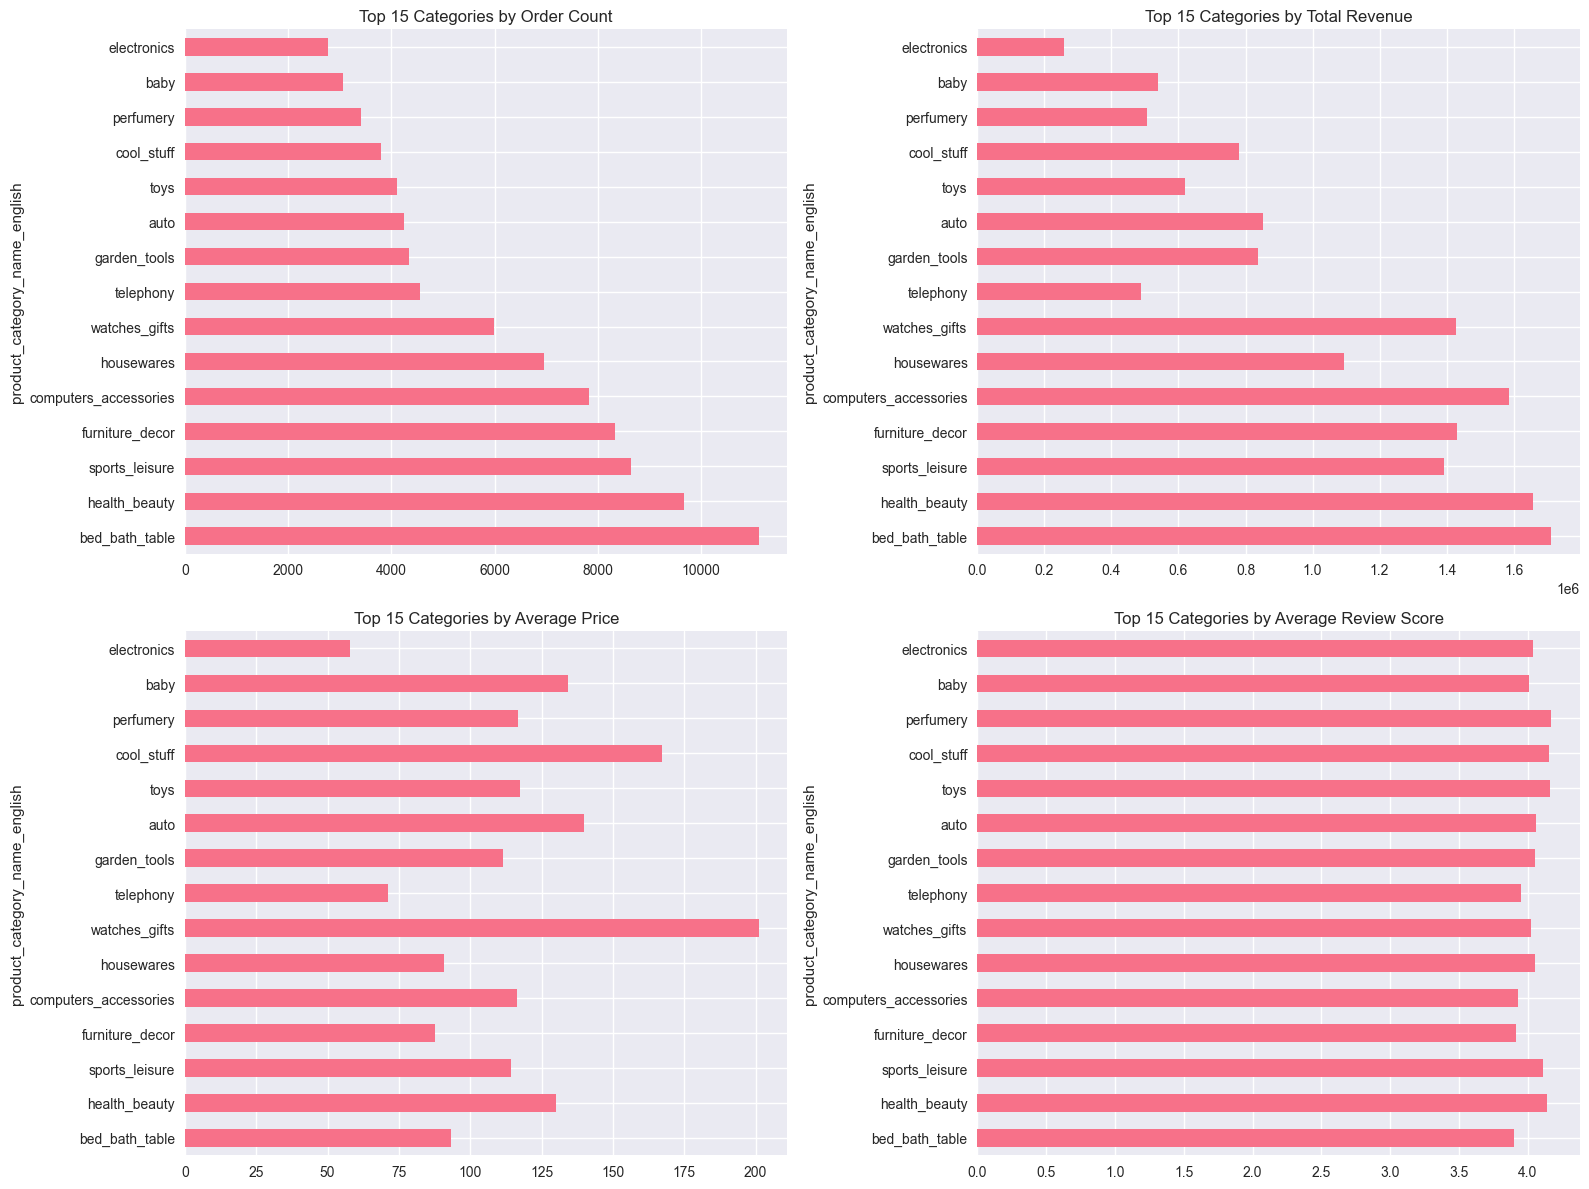

In [15]:
# Product category analysis
if 'product_category_name_english' in df.columns:
    category_analysis = df.groupby('product_category_name_english').agg({
        'order_id': 'count',
        'price': 'mean',
        'total_payment_value': 'sum',
        'avg_review_score': 'mean',
        'freight_value': 'mean'
    }).round(2)
    
    category_analysis.columns = ['Order_Count', 'Avg_Price', 'Total_Revenue', 
                                'Avg_Review_Score', 'Avg_Freight']
    category_analysis = category_analysis.sort_values('Order_Count', ascending=False)
    
    print("TOP 15 PRODUCT CATEGORIES:")
    display(category_analysis.head(15))
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Top categories by order count
    category_analysis.head(15)['Order_Count'].plot(kind='barh', ax=axes[0,0])
    axes[0,0].set_title('Top 15 Categories by Order Count')
    
    # Top categories by revenue
    category_analysis.head(15)['Total_Revenue'].plot(kind='barh', ax=axes[0,1])
    axes[0,1].set_title('Top 15 Categories by Total Revenue')
    
    # Average price by category
    category_analysis.head(15)['Avg_Price'].plot(kind='barh', ax=axes[1,0])
    axes[1,0].set_title('Top 15 Categories by Average Price')
    
    # Average review score by category
    category_analysis.head(15)['Avg_Review_Score'].plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Top 15 Categories by Average Review Score')
    
    plt.tight_layout()
    plt.show()

## 6. Time Series Analysis

In [16]:
# Convert date columns
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 
               'review_creation_date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Extract time features
if 'order_purchase_timestamp' in df.columns:
    df['order_year'] = df['order_purchase_timestamp'].dt.year
    df['order_month'] = df['order_purchase_timestamp'].dt.month
    df['order_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
    df['order_hour'] = df['order_purchase_timestamp'].dt.hour

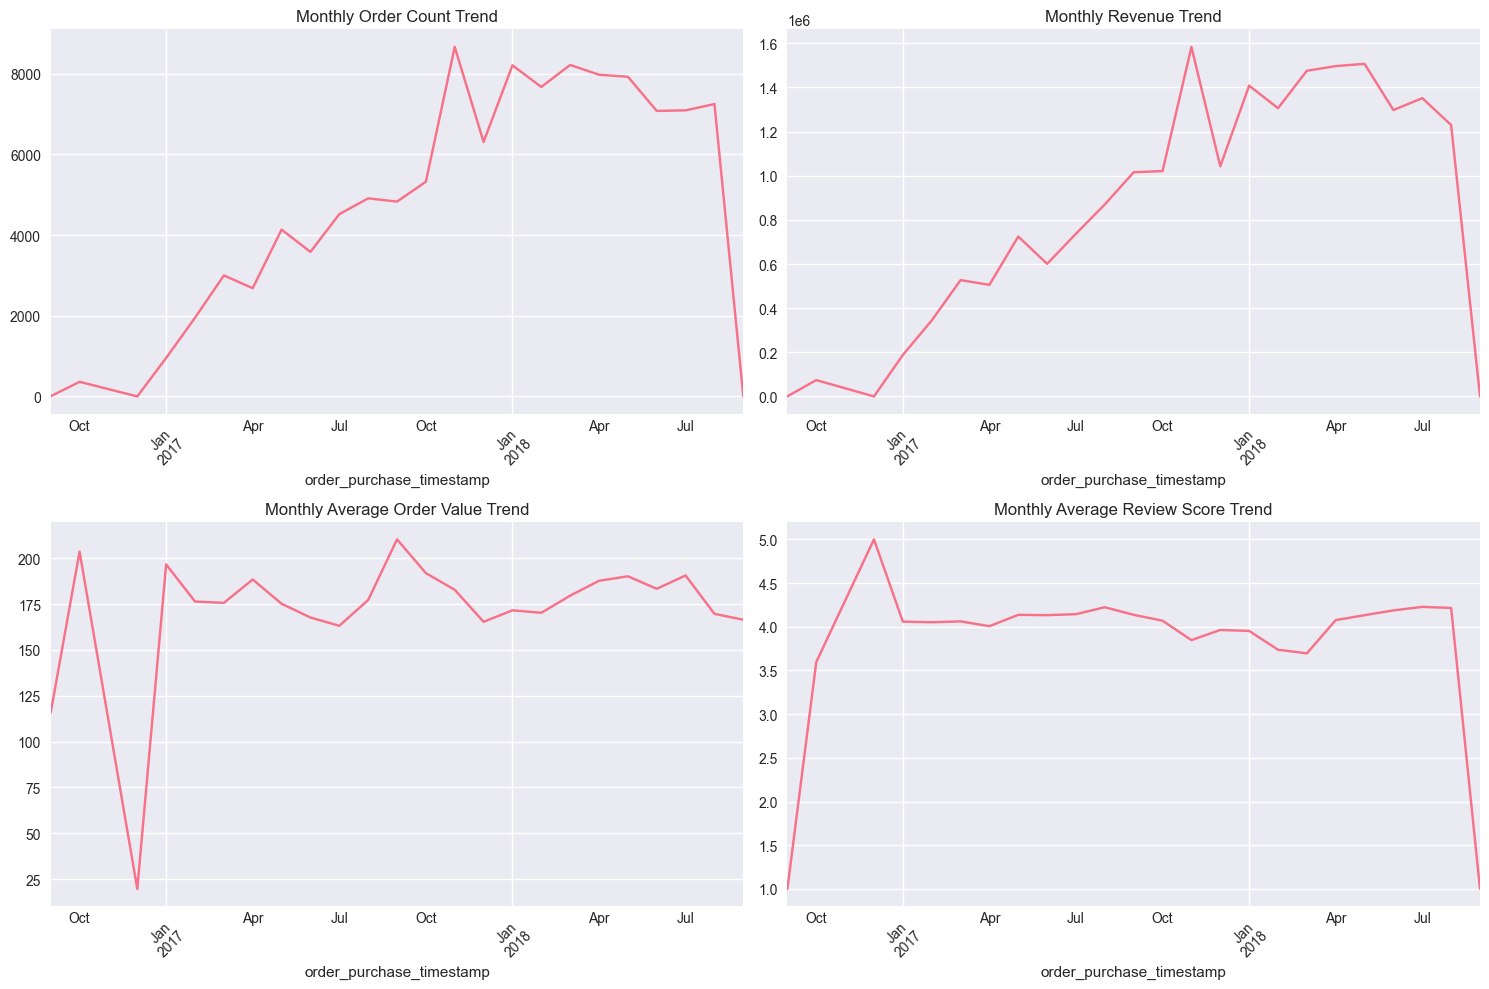

In [17]:
# Monthly trends
if 'order_purchase_timestamp' in df.columns:
    monthly_trends = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({
        'order_id': 'count',
        'total_payment_value': ['sum', 'mean'],
        'avg_review_score': 'mean'
    })
    
    monthly_trends.columns = ['Order_Count', 'Total_Revenue', 'Avg_Order_Value', 'Avg_Review_Score']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Monthly order count
    monthly_trends['Order_Count'].plot(ax=axes[0,0])
    axes[0,0].set_title('Monthly Order Count Trend')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Monthly revenue
    monthly_trends['Total_Revenue'].plot(ax=axes[0,1])
    axes[0,1].set_title('Monthly Revenue Trend')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Average order value
    monthly_trends['Avg_Order_Value'].plot(ax=axes[1,0])
    axes[1,0].set_title('Monthly Average Order Value Trend')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Average review score
    monthly_trends['Avg_Review_Score'].plot(ax=axes[1,1])
    axes[1,1].set_title('Monthly Average Review Score Trend')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

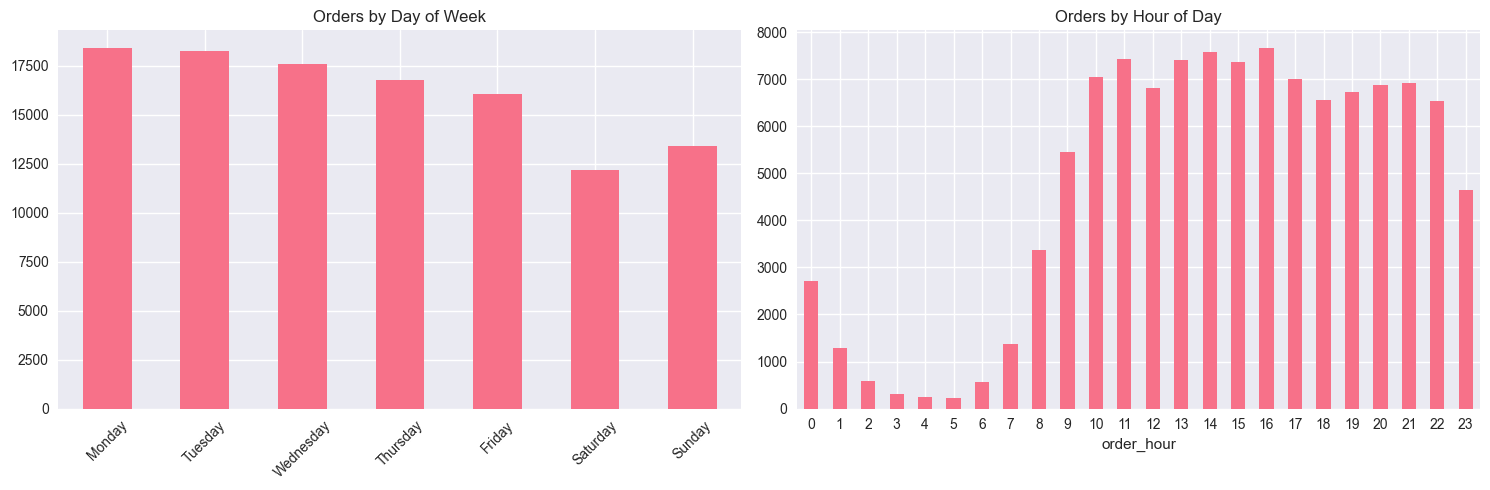

In [18]:
# Day of week and hour analysis
if 'order_day_of_week' in df.columns and 'order_hour' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Orders by day of week
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = df['order_day_of_week'].value_counts().sort_index()
    dow_counts.index = day_names
    dow_counts.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Orders by Day of Week')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Orders by hour
    df['order_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Orders by Hour of Day')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()

## 7. Customer Behavior Analysis

CUSTOMER BEHAVIOR SUMMARY:
Total Unique Customers: 95420
Repeat Customers: 11869
Repeat Customer Rate: 12.44%


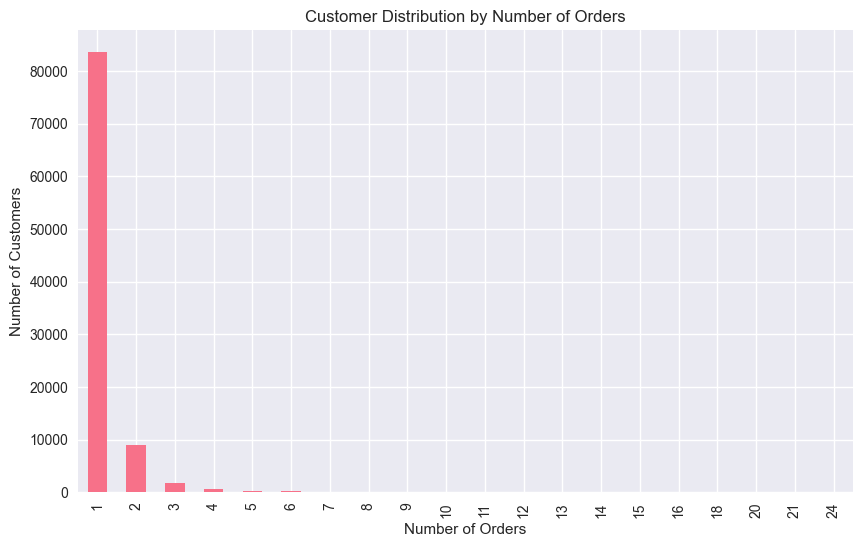


TOP 10 CUSTOMERS BY TOTAL SPENT:


,Order_Count,Total_Spent,Avg_Order_Value,Avg_Review_Score,Avg_Delivery_Days
customer_unique_id,,,,,
0a0a92112bd4c708ca5fde585afaa872,8,109312.64,13664.08,1.0,18.0
698e1cf81d01a3d389d96145f7fa6df8,20,45256.00,2262.80,NaN,10.0
c402f431464c72e27330a67f7b94d4fb,20,44048.00,2202.40,1.0,10.0
4007669dec559734d6f53e029e360987,6,36489.24,6081.54,1.0,19.0
ef8d54b3797ea4db1d63f0ced6a906e9,10,30186.00,3018.60,5.0,14.0
763c8b1c9c68a0229c42c9fc6f662b93,4,29099.52,7274.88,1.0,11.0
c8460e4251689ba205045f3ea17884a1,24,27935.46,1163.98,4.0,12.0
eae0a83d752b1dd32697e0e7b4221656,15,25051.89,1670.13,3.0,35.8
3d47f4368ccc8e1bb4c4a12dbda7111b,10,22346.60,2234.66,1.0,9.0


In [19]:
# Customer analysis
if 'customer_unique_id' in df.columns:
    customer_analysis = df.groupby('customer_unique_id').agg({
        'order_id': 'count',
        'total_payment_value': ['sum', 'mean'],
        'avg_review_score': 'mean',
        'delivery_time_days': 'mean'
    }).round(2)
    
    customer_analysis.columns = ['Order_Count', 'Total_Spent', 'Avg_Order_Value', 
                                'Avg_Review_Score', 'Avg_Delivery_Days']
    
    print("CUSTOMER BEHAVIOR SUMMARY:")
    print(f"Total Unique Customers: {len(customer_analysis)}")
    print(f"Repeat Customers: {(customer_analysis['Order_Count'] > 1).sum()}")
    print(f"Repeat Customer Rate: {(customer_analysis['Order_Count'] > 1).mean():.2%}")
    
    # Customer segmentation by order count
    plt.figure(figsize=(10, 6))
    customer_analysis['Order_Count'].value_counts().sort_index().plot(kind='bar')
    plt.title('Customer Distribution by Number of Orders')
    plt.xlabel('Number of Orders')
    plt.ylabel('Number of Customers')
    plt.show()
    
    # Top customers
    print("\nTOP 10 CUSTOMERS BY TOTAL SPENT:")
    display(customer_analysis.sort_values('Total_Spent', ascending=False).head(10))

## 8. Key Insights and Summary

In [20]:
# Summary statistics
print("=" * 60)
print("KEY BUSINESS INSIGHTS")
print("=" * 60)

# Overall metrics
total_orders = df['order_id'].nunique()
total_customers = df['customer_unique_id'].nunique() if 'customer_unique_id' in df.columns else 'N/A'
total_revenue = df['total_payment_value'].sum() if 'total_payment_value' in df.columns else 'N/A'
avg_order_value = df['total_payment_value'].mean() if 'total_payment_value' in df.columns else 'N/A'
avg_review_score = df['avg_review_score'].mean() if 'avg_review_score' in df.columns else 'N/A'

print(f"BUSINESS OVERVIEW:")
print(f"   • Total Orders: {total_orders:,}")
print(f"   • Total Customers: {total_customers:,}" if total_customers != 'N/A' else f"   • Total Customers: {total_customers}")
print(f"   • Total Revenue: R$ {total_revenue:,.2f}" if total_revenue != 'N/A' else f"   • Total Revenue: {total_revenue}")
print(f"   • Average Order Value: R$ {avg_order_value:.2f}" if avg_order_value != 'N/A' else f"   • Average Order Value: {avg_order_value}")
print(f"   • Average Review Score: {avg_review_score:.2f}/5" if avg_review_score != 'N/A' else f"   • Average Review Score: {avg_review_score}")

# Top performing categories
if 'product_category_name_english' in df.columns:
    top_category = df['product_category_name_english'].value_counts().index[0]
    print(f"\nTOP PERFORMING CATEGORY: {top_category}")

# Geographic insights
if 'customer_state' in df.columns:
    top_state = df['customer_state'].value_counts().index[0]
    print(f"\nTOP STATE BY ORDERS: {top_state}")

# Payment insights
if 'dominant_payment_type' in df.columns:
    top_payment = df['dominant_payment_type'].value_counts().index[0]
    print(f"\nMOST POPULAR PAYMENT METHOD: {top_payment}")

# Delivery insights
if 'delivery_time_days' in df.columns:
    avg_delivery = df['delivery_time_days'].mean()
    print(f"\nAVERAGE DELIVERY TIME: {avg_delivery:.1f} days")

print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY!")
print("=" * 60)

KEY BUSINESS INSIGHTS
BUSINESS OVERVIEW:
   • Total Orders: 98,666
   • Total Customers: 95,420
   • Total Revenue: R$ 20,308,134.71
   • Average Order Value: R$ 180.28
   • Average Review Score: 4.03/5

TOP PERFORMING CATEGORY: bed_bath_table

TOP STATE BY ORDERS: sp

MOST POPULAR PAYMENT METHOD: credit_card

AVERAGE DELIVERY TIME: 12.0 days

EDA COMPLETED SUCCESSFULLY!
